# 实验二十：传统目标识别——最小距离分类器 (压轴实战)

**实验目的：**
体验在没有深度学习的时代，机器是如何利用纯粹的数学特征（形状描述子）和距离度量，完成经典的模式识别与分类任务的。

###  实际应用场景说明
在高度标准化的工业流水线上（如五金件分拣、药片缺陷筛查），使用传统图像特征进行分类依然具有**计算极快、不需要海量数据训练、不需要昂贵 GPU** 的巨大优势。
今天，我们将化身为早期的计算机视觉工程师，从零手写一个“五金零件自动分拣系统”。


In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

def show_images(images, titles, figsize=(15, 4)):
    n = len(images)
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()


## 第一步：构建数据集 (生成圆形垫片与矩形螺栓)
为了证明我们提取的特征具有“旋转和缩放不变性”，我们生成的数据集中，所有的零件大小不一，且摆放角度随机。


 训练数据集生成完毕！展示部分样本：


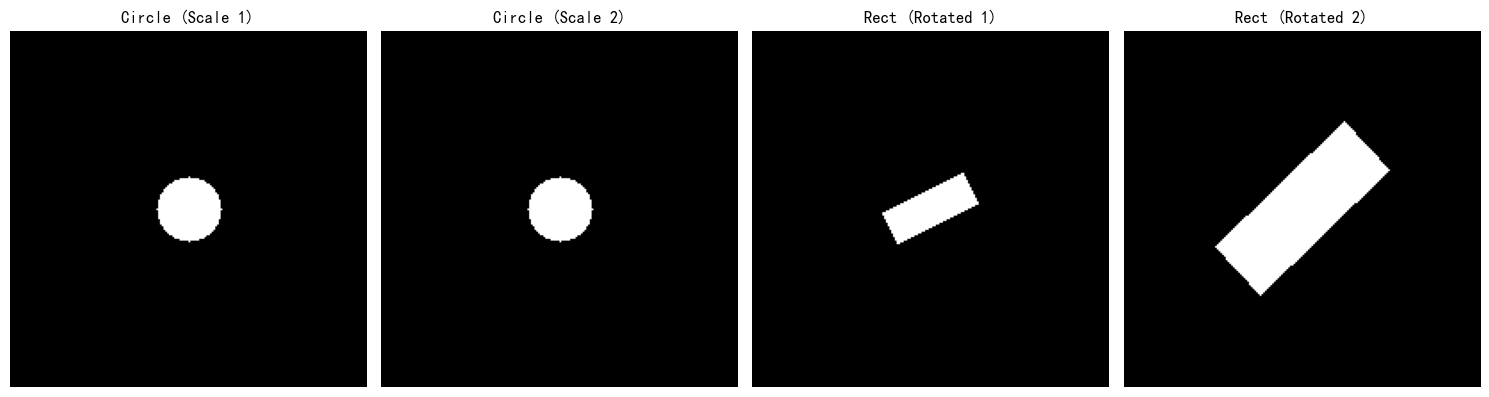

In [24]:
# 辅助函数：生成一张包含特定多边形的图像
def create_part_image(shape_type, scale, angle):
    img = np.zeros((200, 200), dtype=np.uint8)
    center = (100, 100)

    if shape_type == "circle":
        # 生成圆形 (模拟垫片)
        radius = int(30 * scale)
        cv2.circle(img, center, radius, 255, -1)
    elif shape_type == "rect":
        # 生成长方形 (模拟螺栓)
        w, h = int(80 * scale), int(30 * scale)
        rect = ((100, 100), (w, h), angle)
        box = cv2.boxPoints(rect)
        box = np.int32(box)
        cv2.fillPoly(img, [box], 255)

    return img

# --- 1. 生成训练集 ---
train_circles = []
train_rects = []

# 生成 5 个大小不同、角度不同的圆形
for i in range(5):
    scale = np.random.uniform(0.6, 1.5)
    train_circles.append(create_part_image("circle", scale, 0))

# 生成 5 个大小不同、角度不同的矩形
for i in range(5):
    scale = np.random.uniform(0.6, 1.5)
    angle = np.random.uniform(0, 180)
    train_rects.append(create_part_image("rect", scale, angle))

print(" 训练数据集生成完毕！展示部分样本：")
show_images([train_circles[0], train_circles[1], train_rects[0], train_rects[1]], 
            ["Circle (Scale 1)", "Circle (Scale 2)", "Rect (Rotated 1)", "Rect (Rotated 2)"])


## 第二步：特征提取 (Feature Extraction)
这是模式识别最核心的一步！计算机不认识图像，只认识数字。我们要把一整张图像浓缩成 2 个能代表它本质属性的数字：
* **特征 1：致密性 (Compactness) / 圆度**
  公式：$C = \frac{4\pi \times Area}{Perimeter^2}$。如果是完美的圆，$C \approx 1$；如果是细长的矩形，$C$ 会小得多。这招对缩放和旋转免疫。
* **特征 2：Hu矩的第一矩 (Hu Moment 1)**
  由图像的中心距计算而来，对平移、缩放和旋转具有高度的不变性。


In [25]:
def extract_features(img):
    """从二值图像中提取致密性和 Hu 矩特征"""
    # 1. 寻找轮廓
    contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return [0, 0]
    cnt = contours[0]

    # 2. 计算面积和周长
    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    # 特征 1：致密性 (Compactness)
    # 加上 1e-5 防止除以 0
    compactness = (4 * np.pi * area) / (perimeter * perimeter + 1e-5)

    # 3. 计算 Hu 矩
    moments = cv2.moments(cnt)
    hu_moments = cv2.HuMoments(moments)

    # 特征 2：取第一个 Hu 矩 (取对数以缩小数值差异范围)
    hu1 = -np.sign(hu_moments[0][0]) * np.log10(np.abs(hu_moments[0][0]) + 1e-10)

    return [compactness, hu1]

# 提取训练集的特征
features_circle = np.array([extract_features(img) for img in train_circles])
features_rect = np.array([extract_features(img) for img in train_rects])

print(" 特征提取完毕！我们来看看数据长什么样：")
print(f"一个圆形的特征 (圆度, Hu1): {features_circle[0]}")
print(f"一个矩形的特征 (圆度, Hu1): {features_rect[0]}")


 特征提取完毕！我们来看看数据长什么样：
一个圆形的特征 (圆度, Hu1): [0.86129876 0.79785693]
一个矩形的特征 (圆度, Hu1): [0.53368549 0.59591486]


## 第三步：构建二维特征空间与最小距离分类器
我们将提取到的两维特征分别作为 X 轴和 Y 轴，画在散点图上。
你会惊奇地发现：**所有圆形的点聚成了一堆，所有矩形的点聚成了另一堆！**

**最小距离分类器原理：**
1. 分别计算“圆形堆”和“矩形堆”的中心坐标（均值向量）。
2. 当来了一个未知的新零件时，计算它的特征点到这两个中心的**欧式距离**。
3. 离谁更近，它就属于哪一类！


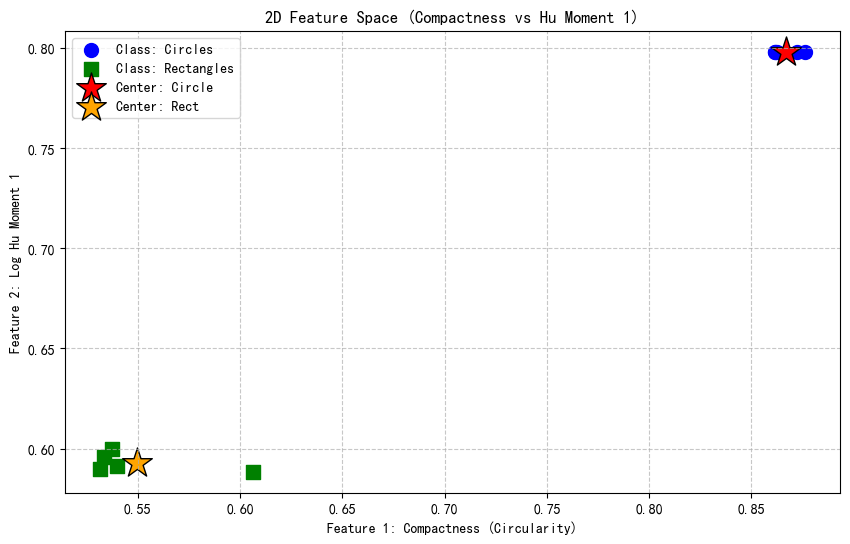

 圆形类中心点坐标: [0.86672101 0.79794982]
 矩形类中心点坐标: [0.54976213 0.59301458]


In [26]:
# 计算两个类别的中心坐标 (均值)
center_circle = np.mean(features_circle, axis=0)
center_rect = np.mean(features_rect, axis=0)

# 绘制二维特征空间散点图
plt.figure(figsize=(10, 6))

# 画出训练样本
plt.scatter(features_circle[:, 0], features_circle[:, 1], c='blue', label='Class: Circles', marker='o', s=100)
plt.scatter(features_rect[:, 0], features_rect[:, 1], c='green', label='Class: Rectangles', marker='s', s=100)

# 画出类别中心 (用巨大的红色和橙色星星表示)
plt.scatter(center_circle[0], center_circle[1], c='red', marker='*', s=500, edgecolors='black', label='Center: Circle')
plt.scatter(center_rect[0], center_rect[1], c='orange', marker='*', s=500, edgecolors='black', label='Center: Rect')

plt.title("2D Feature Space (Compactness vs Hu Moment 1)")
plt.xlabel("Feature 1: Compactness (Circularity)")
plt.ylabel("Feature 2: Log Hu Moment 1")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(f" 圆形类中心点坐标: {center_circle}")
print(f" 矩形类中心点坐标: {center_rect}")


## 第四步：模型测试 / 推理 (Inference)
现在，流水线上送来了两个**我们从未见过的新零件**。
一个是极其细长的长方形（严重倾斜），另一个是特别微小的圆形。
让我们的最小距离分类器来看看它们到底是谁！


 测试样本 1 预测结果: Rectangle (Bolt)
   距离圆心: 0.2968, 距离矩形心: 0.0883
 测试样本 2 预测结果: Circle (Washer)
   距离圆心: 0.0133, 距离矩形心: 0.3657


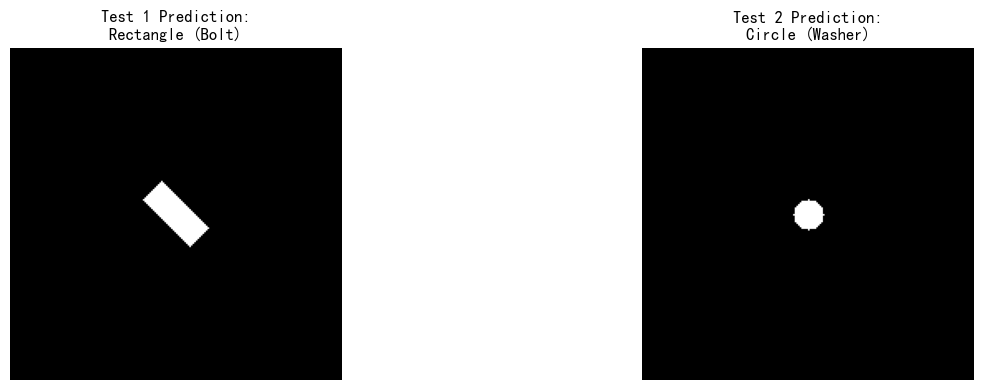

In [27]:
# --- 1. 生成未知的测试样本 ---
# 测试样本 1：极其细长且倾斜 45 度的矩形
test_img_1 = create_part_image("rect", scale=0.5, angle=45) 
# 测试样本 2：极小的圆形
test_img_2 = create_part_image("circle", scale=0.3, angle=0)

# --- 2. 提取特征 ---
feat_test_1 = extract_features(test_img_1)
feat_test_2 = extract_features(test_img_2)

# --- 3. 分类器推理逻辑 ---
def classify_unknown_part(feat_vector):
    # 计算到圆形中心的欧式距离
    dist_to_circle = np.linalg.norm(feat_vector - center_circle)
    # 计算到矩形中心的欧式距离
    dist_to_rect = np.linalg.norm(feat_vector - center_rect)

    if dist_to_circle < dist_to_rect:
        return "Circle (Washer)", dist_to_circle, dist_to_rect
    else:
        return "Rectangle (Bolt)", dist_to_circle, dist_to_rect

# --- 4. 进行预测 ---
pred_1, d1_c, d1_r = classify_unknown_part(feat_test_1)
pred_2, d2_c, d2_r = classify_unknown_part(feat_test_2)

print("==================================================")
print(f" 测试样本 1 预测结果: {pred_1}")
print(f"   距离圆心: {d1_c:.4f}, 距离矩形心: {d1_r:.4f}")
print("==================================================")
print(f" 测试样本 2 预测结果: {pred_2}")
print(f"   距离圆心: {d2_c:.4f}, 距离矩形心: {d2_r:.4f}")
print("==================================================")

# 可视化测试结果
show_images([test_img_1, test_img_2], 
            [f"Test 1 Prediction:\n{pred_1}", f"Test 2 Prediction:\n{pred_2}"])


#  实验总结：传统目标识别——最小距离分类器

本实验通过纯粹的几何特征提取与统计学距离度量，从零构建了一个完整的“五金零件自动分拣系统”。实验避开了复杂的神经网络黑盒，直击模式识别（Pattern Recognition）的底层数学逻辑，展示了计算机如何通过数值特征来“认知”和“分类”不同的物体。



##   实验核心技术拆解

本实验的成功运行依赖于三大核心步骤：

* **构建具有“不变性”的特征集（Feature Invariance）：**
    在真实的工业流水线上，零件的摆放位置、相机的高度（缩放）、零件的角度往往是随机的。因此，我们提取的特征必须具备**平移、缩放、旋转不变性**，才能保证同一类物体在任何状态下都能被识别。
* **特征降维与提取（Feature Extraction）：**
    我们将包含数万个像素点的图像，极致压缩为 **2 个最具代表性的核心数字**：
    1.  **致密性（圆度 / Compactness）：** 公式为 $C = \frac{4\pi \times Area}{Perimeter^2}$。如果是完美的圆，$C \approx 1$；如果是细长的矩形，$C$ 会小得多。这一特征对缩放和旋转免疫。
    2.  **Hu 矩（第一矩）：** 利用图像的中心距计算得出，进一步巩固了形状的尺度与旋转不变性。
* **最小距离决策（Minimum Distance Classifier）：**
    将提取到的两个特征作为 X 轴和 Y 轴，在二维特征空间中计算各类样本的“均值中心”。当面临未知样本时，计算其与各个类别中心的**欧式距离（Euclidean Distance）**，遵循“离谁近就属于哪一类”的朴素逻辑完成分类。

##   实验现象背后的数学逻辑

本实验中最具启发性的环节是**绘制 2D 特征空间散点图**：
在肉眼中大小各异、倾斜歪扭的零件图像，一旦经过上述数学公式的“洗礼”，在坐标系中就会极其规律地聚集成“泾渭分明”的几个簇（Clusters）。这直观地证明了：只要找对了特征，杂乱无章的像素矩阵就能转化为高度结构化的数学空间。这就是“物以类聚”在几何空间中的真实形态，也是 K-Means 等现代聚类算法的思想基石。

##   工程价值与工业应用

在深度学习高度发达的今天，这种传统的特征工程分类器依然在高度标准化的场景（如工业缺陷检测、药片筛查、五金件分拣）中具备不可替代的优势：
1.  **极其轻量高效：** 只需要几行基础的 CPU 运算代码，毫秒级响应，无需昂贵的 GPU 算力。
2.  **极低的数据依赖：** 不需要收集和标注几万张照片，只需少量几个样本计算出类别中心即可稳定工作。
3.  **绝对的可解释性：** 整个分类过程完全透明。如果分类出现错误，工程师可以通过特征坐标图精准排查出是“圆度”阈值设定有误，还是“Hu矩”受到了噪点干扰，便于快速调试与优化。